In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
%matplotlib inline

In [3]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [4]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [5]:
df.shape

(1000, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [9]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [10]:
#Average math marks
avg_math = float(df['math score'].mean())
print('The average math score is avg_math ')

The average math score is avg_math 


In [11]:
#Average reading marks
avg_reading = float(df['reading score'].mean())
print(f'The average math score is {avg_reading} ')

The average math score is 69.169 


In [12]:
#Average reading marks
avg_writing = float(df['writing score'].mean())
print(f'The average math score is {avg_writing} ')

The average math score is 68.054 


In [13]:
#Topper finder
df['total marks'] = df['math score'] + df['reading score'] + df['writing score']
df1 = df[df["total marks"] == df["total marks"].max()]
df1


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total marks
458,female,group E,bachelor's degree,standard,none,100,100,100,300
916,male,group E,bachelor's degree,standard,completed,100,100,100,300
962,female,group E,associate's degree,standard,none,100,100,100,300


In [14]:
#Topper finder by sorting
df3 = df.sort_values(by = 'total marks',ascending = False)
df3.iloc[[0,1,2]]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total marks
916,male,group E,bachelor's degree,standard,completed,100,100,100,300
458,female,group E,bachelor's degree,standard,none,100,100,100,300
962,female,group E,associate's degree,standard,none,100,100,100,300


In [15]:
#topper finder between male and female
max_marks = df['total marks'].max()
df[df['total marks'] == max_marks].groupby('gender')['total marks'].count()



gender
female    2
male      1
Name: total marks, dtype: int64

In [16]:
#gender analysis who score better on average
df.groupby('gender')['total marks'].mean()

gender
female    208.708494
male      197.512448
Name: total marks, dtype: float64

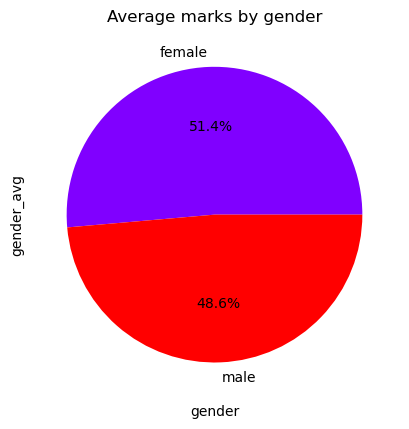

In [20]:
#making comparison chart
gender_avg = df.groupby('gender')['total marks'].mean()
gender_avg.plot(kind = 'pie', autopct='%1.1f%%', colormap = 'rainbow')
plt.title('Average marks by gender')
plt.xlabel('gender')
plt.ylabel('gender_avg')
plt.savefig('charts/gender_chart.png')
plt.show()

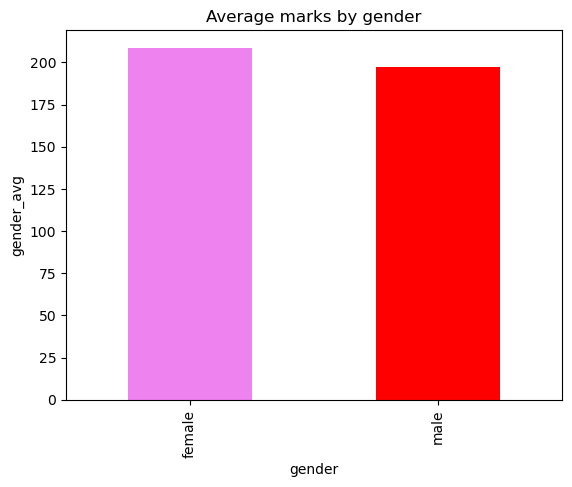

In [21]:
gender_avg.plot(kind = 'bar', color = ['violet','red'])
plt.title('Average marks by gender')
plt.xlabel('gender')
plt.ylabel('gender_avg')
plt.savefig('charts/gender_chart_barplot.png')
plt.show()

In [19]:
#does parental education affect student result
df.groupby('parental level of education')['total marks'].mean()

parental level of education
associate's degree    208.707207
bachelor's degree     215.771186
high school           189.290816
master's degree       220.796610
some college          205.429204
some high school      195.324022
Name: total marks, dtype: float64

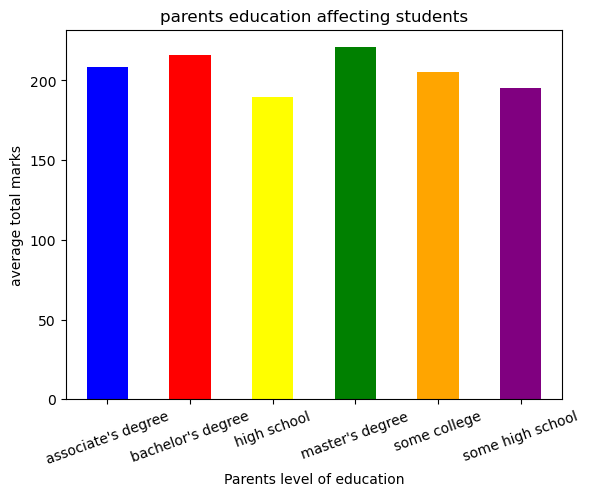

In [22]:
Parental_education = df.groupby('parental level of education')['total marks'].mean()
Parental_education.plot(kind = 'bar', color = ['blue','red','yellow','green','orange','purple'])
plt.title('parents education affecting students')
plt.xlabel('Parents level of education')
plt.ylabel('average total marks')
plt.xticks(rotation = 20)
plt.savefig('charts/parents_student chart.png')
plt.show()

In [32]:
#Lunch impact analysis
df.groupby('lunch')['total marks'].mean()

lunch
free/reduced    186.597183
standard        212.511628
Name: total marks, dtype: float64

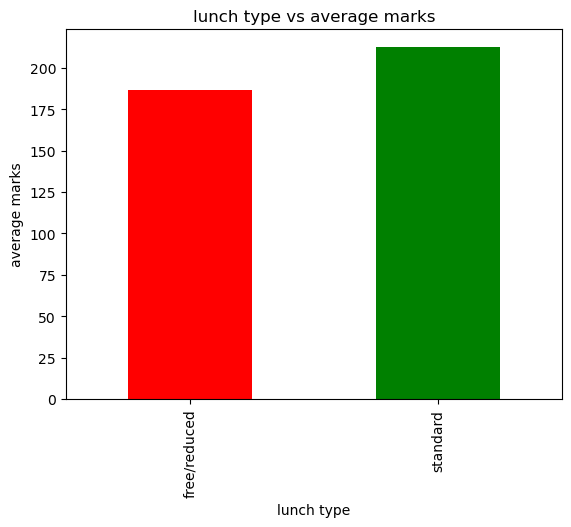

In [23]:
lunch_avg = df.groupby('lunch')['total marks'].mean()
lunch_avg.plot(kind = 'bar', color = ['red','green'])
plt.title('lunch type vs average marks')
plt.xlabel('lunch type')
plt.ylabel('average marks')
plt.savefig('charts/lunch_studens-marks.png')
plt.show()

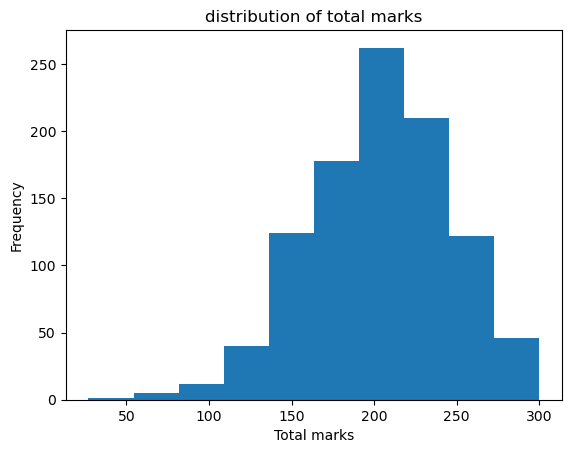

In [39]:
#histogramplot to find marks distribution
df['total marks'].plot(kind = 'hist')
plt.title('distribution of total marks')
plt.xlabel('Total marks')
plt.savefig('charts/historgram_chart_of_marks_disrtribution.png')
plt.show()

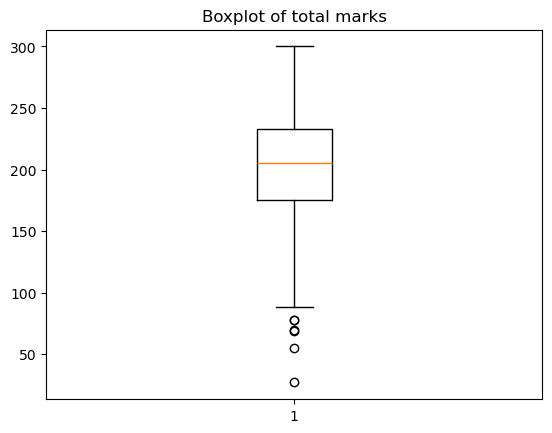

In [25]:
#Boxplot to find median,range,unusual scores
plt.boxplot(df['total marks'])
plt.title('Boxplot of total marks')
plt.savefig('charts/boxplot_chart_of total marks.png')
plt.show()

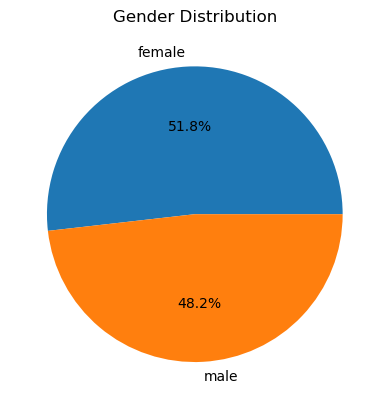

In [26]:
#gender percentage in dataset
gender_count = df['gender'].value_counts()

gender_count.plot(kind='pie', autopct='%1.1f%%')

plt.title('Gender Distribution')

plt.ylabel('')

plt.show()